# GPS-Free Localization Test: Drone Route over Vejle - ROADS, LAND & BUILDINGS

This notebook tests the complete localization pipeline on a real drone flight route using **roads, land, and building features**.

## Pipeline:
1. **Load trained semantic segmentation model** (UNet++ with EfficientNet-B3)
2. **Process ALL drone images** (Capture00022756 - Capture00024091)
3. **Generate semantic masks** with the model
4. **Extract road, land, and building landmarks** (classes 2, 4, 5) - filters out forest/water to address domain shift
5. **Query reference database** for best matches
6. **Display localization results** with GPS coordinates

**Dataset:** 1200ft AMSL 15fps drone flight over Vejle, Denmark  
**Key difference:** This test uses **ROADS, LAND, AND BUILDINGS** to avoid misclassification issues between forest/water in flight simulator vs TMS imagery.

**Hypothesis:** Road, land, and building topology should be more stable across different imagery domains than forest/water boundaries.

## 1. Setup and Model Loading

In [16]:
# Imports
import os
import sys
import json
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')
from tqdm.auto import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

# Add localization package to path
sys.path.insert(0, str(Path.cwd()))

# Import localization modules
from localization import (
    extract_centroids, 
    compute_feature_vector,
    normalize_feature_vector,
    ReferenceDatabase
)
from localization.utils import (
    visualize_landmarks,
    rgb_to_class_id,
    create_color_map
)

print("✓ Imports successful")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✓ Imports successful
Device: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


In [17]:
# ========================================
# CONFIGURATION - ROADS, LAND, AND BUILDINGS TEST
# ========================================

# Paths
BASE_DIR = Path(r"C:\Users\emilj\Documents\Thesis\TRAINING")
DRONE_IMAGES_DIR = BASE_DIR / "REFERENCE MAP CROPPED" / "aerial" / "1200ft AMSL 15fps"
MODEL_PATH = BASE_DIR / "runs" / "20260317_152458_pipelineA" / "best.pth"
DATABASE_PATH = BASE_DIR / "localization_output" / "reference_database_vejle.h5"

# Output - NEW DIRECTORY FOR ROADS+LAND+BUILDINGS TEST
OUTPUT_DIR = BASE_DIR / "localization_output" / "drone_route_test_roads_land_buildings_summer_model_1"
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# Test range (Capture00022756 to Capture00024091)
START_FRAME = 22756
END_FRAME = 24091
SAMPLE_EVERY = 1  # Process EVERY frame (no sampling)

# Model configuration
CLASS_NAMES = [
    'waterbodies',
    'forest_trees', 
    'land',
    'railway',
    'roads',
    'buildings'
]

COLOR_MAP = {
    0: (4, 4, 255),        # waterbodies - blue
    1: (0, 167, 2),        # forest_trees - green
    2: (243, 255, 150),    # land - yellow
    3: (193, 105, 53),     # railway - brown
    4: (255, 0, 231),      # roads - magenta
    5: (150, 150, 150)     # buildings - gray
}

NUM_CLASSES = len(CLASS_NAMES)
INPUT_SIZE = 256  # Model trained on 256x256 images

# Feature extraction parameters (must match database)
MIN_LANDMARK_AREA = 100
MAX_TRIPLETS = 50
TOP_K_MATCHES = 5  # Return top 5 location matches

print("="*60)
print("DRONE ROUTE LOCALIZATION TEST - ROADS, LAND & BUILDINGS")
print("="*60)
print(f"Drone images: {DRONE_IMAGES_DIR}")
print(f"Frame range: {START_FRAME} to {END_FRAME} (every {SAMPLE_EVERY}th)")
print(f"Model: {MODEL_PATH}")
print(f"Database: {DATABASE_PATH}")
print(f"Output: {OUTPUT_DIR}")
print(f"FILTER: ROADS (class 4) + LAND (class 2) + BUILDINGS (class 5)")
print("="*60)

DRONE ROUTE LOCALIZATION TEST - ROADS, LAND & BUILDINGS
Drone images: C:\Users\emilj\Documents\Thesis\TRAINING\REFERENCE MAP CROPPED\aerial\1200ft AMSL 15fps
Frame range: 22756 to 24091 (every 1th)
Model: C:\Users\emilj\Documents\Thesis\TRAINING\runs\20260317_152458_pipelineA\best.pth
Database: C:\Users\emilj\Documents\Thesis\TRAINING\localization_output\reference_database_vejle.h5
Output: C:\Users\emilj\Documents\Thesis\TRAINING\localization_output\drone_route_test_roads_land_buildings_summer_model_1
FILTER: ROADS (class 4) + LAND (class 2) + BUILDINGS (class 5)


In [18]:
# Load semantic segmentation model
print("\nLoading semantic segmentation model...")

# Create model architecture (same as training)
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b3",
    encoder_weights=None,  # Will load from checkpoint
    in_channels=3,
    classes=NUM_CLASSES,
    decoder_attention_type='scse',  # IMPORTANT: Must match training config (spatial and channel squeeze & excitation)
    activation=None  # Will apply softmax later
)

# Load checkpoint
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print(f"✓ Model loaded from {MODEL_PATH}")
print(f"  Architecture: UNet++ with EfficientNet-B3 + scSE attention")
print(f"  Epoch: {checkpoint.get('epoch', 'unknown')}")
if 'best_iou' in checkpoint:
    print(f"  Best IoU: {checkpoint['best_iou']:.4f}")

# Setup inference transform (no augmentation, just normalization)
transform = A.Compose([
    A.Resize(INPUT_SIZE, INPUT_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])


Loading semantic segmentation model...
✓ Model loaded from C:\Users\emilj\Documents\Thesis\TRAINING\runs\20260317_152458_pipelineA\best.pth
  Architecture: UNet++ with EfficientNet-B3 + scSE attention
  Epoch: 24
  Best IoU: 0.6679


In [19]:
# Load reference database
print("\nLoading reference database...")

database = ReferenceDatabase()
database.load(str(DATABASE_PATH))

print(f"✓ Database loaded: {len(database)} entries")
stats = database.get_statistics()
print(f"  Total landmarks: {stats['total_landmarks']:,}")
print(f"  Feature dimension: {stats['feature_dimension']}")
print(f"  Coverage: Vejle, Denmark")


Loading reference database...
✓ Database loaded: 258 entries
  Total landmarks: 12,964
  Feature dimension: 350
  Coverage: Vejle, Denmark


## 2. Inference Helper Functions

In [20]:
def predict_mask(model, image_path, transform, device):
    """
    Run semantic segmentation on a single image.
    
    Returns:
        rgb_mask: RGB visualization (H, W, 3)
        class_mask: Class IDs (H, W)
    """
    # Load image
    img = np.array(Image.open(image_path).convert('RGB'))
    original_size = img.shape[:2]
    
    # Transform and predict
    transformed = transform(image=img)
    img_tensor = transformed['image'].unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(img_tensor)
        pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
    
    # Resize back to original size
    pred_resized = np.array(Image.fromarray(pred.astype(np.uint8)).resize(
        (original_size[1], original_size[0]), 
        Image.NEAREST
    ))
    
    # Convert to RGB visualization
    rgb_mask = np.zeros((*pred_resized.shape, 3), dtype=np.uint8)
    for class_id, color in COLOR_MAP.items():
        rgb_mask[pred_resized == class_id] = color
    
    return rgb_mask, pred_resized


def localize_image(image_path, model, transform, database, device, 
                   min_area=100, max_triplets=50, top_k=5):
    """
    Complete localization pipeline for one image.
    **ROADS, LAND, AND BUILDINGS** - Filters to classes 2 (land), 4 (roads), and 5 (buildings) to avoid forest/water misclassification
    
    Returns:
        dict with 'image', 'mask', 'landmarks', 'matches', 'success'
    """
    result = {
        'image_path': str(image_path),
        'success': False,
        'error': None
    }
    
    try:
        # 1. Load original image
        original_image = np.array(Image.open(image_path).convert('RGB'))
        result['image'] = original_image
        
        # 2. Generate semantic mask
        rgb_mask, class_mask = predict_mask(model, image_path, transform, device)
        result['mask'] = rgb_mask
        result['class_mask'] = class_mask
        
        # 3. Extract landmarks - ROADS, LAND, AND BUILDINGS (classes 2, 4, 5)
        # This filters to only road, land, and building pixels to avoid domain shift issues with forest/water
        landmarks = extract_centroids(
            class_mask,
            class_names=CLASS_NAMES,
            min_area=min_area,
            filter_classes=[2, 4, 5]  # LAND (2), ROADS (4), and BUILDINGS (5)
        )
        result['landmarks'] = landmarks
        result['num_landmarks'] = len(landmarks)
        
        if len(landmarks) < 3:
            result['error'] = f"Not enough landmarks ({len(landmarks)} < 3)"
            return result
        
        # 4. Compute feature vector
        feature_vector = compute_feature_vector(
            landmarks,
            max_triplets=max_triplets,
            min_distance=10.0
        )
        feature_vector = normalize_feature_vector(feature_vector, exclude_semantic=True)
        result['features'] = feature_vector
        
        # 5. Query database
        matches = database.query_by_features(feature_vector, top_k=top_k)
        result['matches'] = matches
        result['success'] = True
        
        # Add best match info
        if matches:
            best = matches[0]['metadata']
            result['estimated_lat'] = best['lat']
            result['estimated_lon'] = best['lon']
            result['confidence'] = 1.0 / (1.0 + matches[0]['distance'])  # Simple confidence metric
            result['top_match_distance'] = matches[0]['distance']
        
        return result
        
    except Exception as e:
        result['error'] = str(e)
        return result

def predict_mask_with_rotation(model, image, transform, device, rotation=0):
    """
    Run semantic segmentation on an image with optional rotation.
    
    Args:
        model: Segmentation model
        image: numpy array (H, W, 3)
        transform: Albumentations transform
        device: torch device
        rotation: Rotation angle in degrees (0, 90, 180, 270)
    
    Returns:
        class_mask: Class IDs (H, W) - rotated back to original orientation
    """
    original_size = image.shape[:2]
    
    # Rotate image if needed
    if rotation == 90:
        img_rotated = np.rot90(image, k=1)
    elif rotation == 180:
        img_rotated = np.rot90(image, k=2)
    elif rotation == 270:
        img_rotated = np.rot90(image, k=3)
    else:
        img_rotated = image
    
    # Transform and predict
    transformed = transform(image=img_rotated)
    img_tensor = transformed['image'].unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(img_tensor)
        pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
    
    # Rotate prediction back to original orientation
    if rotation == 90:
        pred = np.rot90(pred, k=3)  # Rotate back (opposite direction)
    elif rotation == 180:
        pred = np.rot90(pred, k=2)
    elif rotation == 270:
        pred = np.rot90(pred, k=1)
    
    # Resize back to original size
    pred_resized = np.array(Image.fromarray(pred.astype(np.uint8)).resize(
        (original_size[1], original_size[0]), 
        Image.NEAREST
    ))
    
    return pred_resized


def localize_image_tta(image_path, model, transform, database, device, 
                       min_area=100, max_triplets=50, top_k=5, rotations=[0, 90, 180, 270]):
    """
    Complete localization pipeline with Test-Time Augmentation (TTA).
    Runs inference on multiple rotations and aggregates results for better robustness.
    
    Args:
        rotations: List of rotation angles to test (default: [0, 90, 180, 270])
    
    Returns:
        dict with 'image', 'mask', 'landmarks', 'matches', 'success', 'tta_votes'
    """
    result = {
        'image_path': str(image_path),
        'success': False,
        'error': None,
        'tta_results': []
    }
    
    try:
        # 1. Load original image
        original_image = np.array(Image.open(image_path).convert('RGB'))
        result['image'] = original_image
        
        # 2. Run inference on all rotations
        all_matches = []
        valid_rotations = []
        
        for rotation in rotations:
            try:
                # Generate semantic mask with rotation
                class_mask = predict_mask_with_rotation(model, original_image, transform, device, rotation)
                
                # Extract landmarks
                landmarks = extract_centroids(
                    class_mask,
                    class_names=CLASS_NAMES,
                    min_area=min_area,
                    filter_classes=[2, 4, 5]  # LAND (2), ROADS (4), and BUILDINGS (5)
                )
                
                if len(landmarks) < 3:
                    continue
                
                # Compute feature vector
                feature_vector = compute_feature_vector(
                    landmarks,
                    max_triplets=max_triplets,
                    min_distance=10.0
                )
                feature_vector = normalize_feature_vector(feature_vector, exclude_semantic=True)
                
                # Query database
                matches = database.query_by_features(feature_vector, top_k=top_k)
                
                if matches:
                    all_matches.append({
                        'rotation': rotation,
                        'matches': matches,
                        'landmarks': landmarks,
                        'class_mask': class_mask
                    })
                    valid_rotations.append(rotation)
                    
            except Exception as e:
                # Skip this rotation if it fails
                continue
        
        if len(all_matches) == 0:
            result['error'] = f"No valid matches from any rotation (tested: {rotations})"
            return result
        
        # 3. Aggregate results using weighted voting
        # Count votes for each location, weighted by inverse distance
        location_votes = {}
        
        for rot_result in all_matches:
            for match in rot_result['matches']:
                meta = match['metadata']
                location_key = (meta['tile_x'], meta['tile_y'])
                
                # Weight by inverse distance (better matches get higher weight)
                weight = 1.0 / (1.0 + match['distance'])
                
                if location_key not in location_votes:
                    location_votes[location_key] = {
                        'total_weight': 0,
                        'count': 0,
                        'metadata': meta,
                        'min_distance': match['distance']
                    }
                
                location_votes[location_key]['total_weight'] += weight
                location_votes[location_key]['count'] += 1
                location_votes[location_key]['min_distance'] = min(
                    location_votes[location_key]['min_distance'], 
                    match['distance']
                )
        
        # 4. Sort by total weight (best consensus)
        sorted_locations = sorted(
            location_votes.items(), 
            key=lambda x: (x[1]['count'], x[1]['total_weight']), 
            reverse=True
        )
        
        # 5. Build final result from best consensus
        best_location_key, best_vote_info = sorted_locations[0]
        best_meta = best_vote_info['metadata']
        
        result['success'] = True
        result['estimated_lat'] = best_meta['lat']
        result['estimated_lon'] = best_meta['lon']
        result['confidence'] = best_vote_info['total_weight'] / len(rotations)
        result['top_match_distance'] = best_vote_info['min_distance']
        result['tta_votes'] = best_vote_info['count']  # How many rotations agreed
        result['tta_rotations_tested'] = len(all_matches)
        result['tta_results'] = all_matches
        
        # Use mask and landmarks from first successful rotation
        result['mask'] = all_matches[0]['class_mask']
        result['landmarks'] = all_matches[0]['landmarks']
        result['num_landmarks'] = len(all_matches[0]['landmarks'])
        
        # Build matches list from aggregated results
        result['matches'] = []
        for idx, (loc_key, vote_info) in enumerate(sorted_locations[:top_k]):
            result['matches'].append({
                'rank': idx + 1,
                'distance': vote_info['min_distance'],
                'metadata': vote_info['metadata'],
                'tta_votes': vote_info['count']
            })
        
        return result
        
    except Exception as e:
        result['error'] = str(e)
        return result


print("✓ Inference functions defined (ROADS, LAND, AND BUILDINGS mode)")
print("✓ Test-Time Augmentation (TTA) with rotation enabled")

✓ Inference functions defined (ROADS, LAND, AND BUILDINGS mode)
✓ Test-Time Augmentation (TTA) with rotation enabled


## 3. Test on Sample Images

In [21]:
# Find drone images in range
all_images = sorted(list(DRONE_IMAGES_DIR.glob("Capture*.jpeg")))
print(f"\nFound {len(all_images)} total images in directory")

# Filter to range
test_images = []
for img_path in all_images:
    frame_num = int(img_path.stem.replace('Capture', ''))
    if START_FRAME <= frame_num <= END_FRAME:
        test_images.append(img_path)

print(f"Images in range ({START_FRAME}-{END_FRAME}): {len(test_images)}")

# Sample every Nth image
sampled_images = test_images[::SAMPLE_EVERY]
print(f"Sampling every {SAMPLE_EVERY}th image: {len(sampled_images)} frames")
print(f"First: {sampled_images[0].name}")
print(f"Last: {sampled_images[-1].name}")


Found 1758 total images in directory
Images in range (22756-24091): 90
Sampling every 1th image: 90 frames
First: Capture00022756.jpeg
Last: Capture00024091.jpeg


In [22]:
# Test on first sample image
print("\n" + "="*60)
print("TESTING ON FIRST SAMPLE IMAGE")
print("="*60)

test_img = sampled_images[0]
print(f"\nProcessing: {test_img.name}")

result = localize_image(
    test_img, 
    model, 
    transform, 
    database, 
    device,
    min_area=MIN_LANDMARK_AREA,
    max_triplets=MAX_TRIPLETS,
    top_k=TOP_K_MATCHES
)

if result['success']:
    print(f"\n✓ Localization successful!")
    print(f"  Landmarks extracted: {result['num_landmarks']}")
    print(f"  Feature vector: {result['features'].shape}")
    print(f"\n  Estimated Position:")
    print(f"    Latitude: {result['estimated_lat']:.6f}°")
    print(f"    Longitude: {result['estimated_lon']:.6f}°")
    print(f"    Confidence: {result['confidence']:.3f}")
    
    print(f"\n  Top {TOP_K_MATCHES} Matches:")
    for match in result['matches']:
        meta = match['metadata']
        print(f"    Rank {match['rank']}: Distance={match['distance']:.3f}")
        print(f"      Lat/Lon: ({meta['lat']:.6f}, {meta['lon']:.6f})")
        print(f"      Tile: ({meta['tile_x']}, {meta['tile_y']})")
else:
    print(f"\n✗ Localization failed: {result['error']}")


TESTING ON FIRST SAMPLE IMAGE

Processing: Capture00022756.jpeg

✓ Localization successful!
  Landmarks extracted: 3
  Feature vector: (350,)

  Estimated Position:
    Latitude: 55.717829°
    Longitude: 9.492188°
    Confidence: 0.044

  Top 5 Matches:
    Rank 1: Distance=21.654
      Lat/Lon: (55.717829, 9.492188)
      Tile: (34496, 45036)
    Rank 2: Distance=23.899
      Lat/Lon: (55.711640, 9.486694)
      Tile: (34495, 45034)
    Rank 3: Distance=24.632
      Lat/Lon: (55.689972, 9.497681)
      Tile: (34497, 45027)
    Rank 4: Distance=25.752
      Lat/Lon: (55.686875, 9.497681)
      Tile: (34497, 45026)
    Rank 5: Distance=26.032
      Lat/Lon: (55.702355, 9.558105)
      Tile: (34508, 45031)


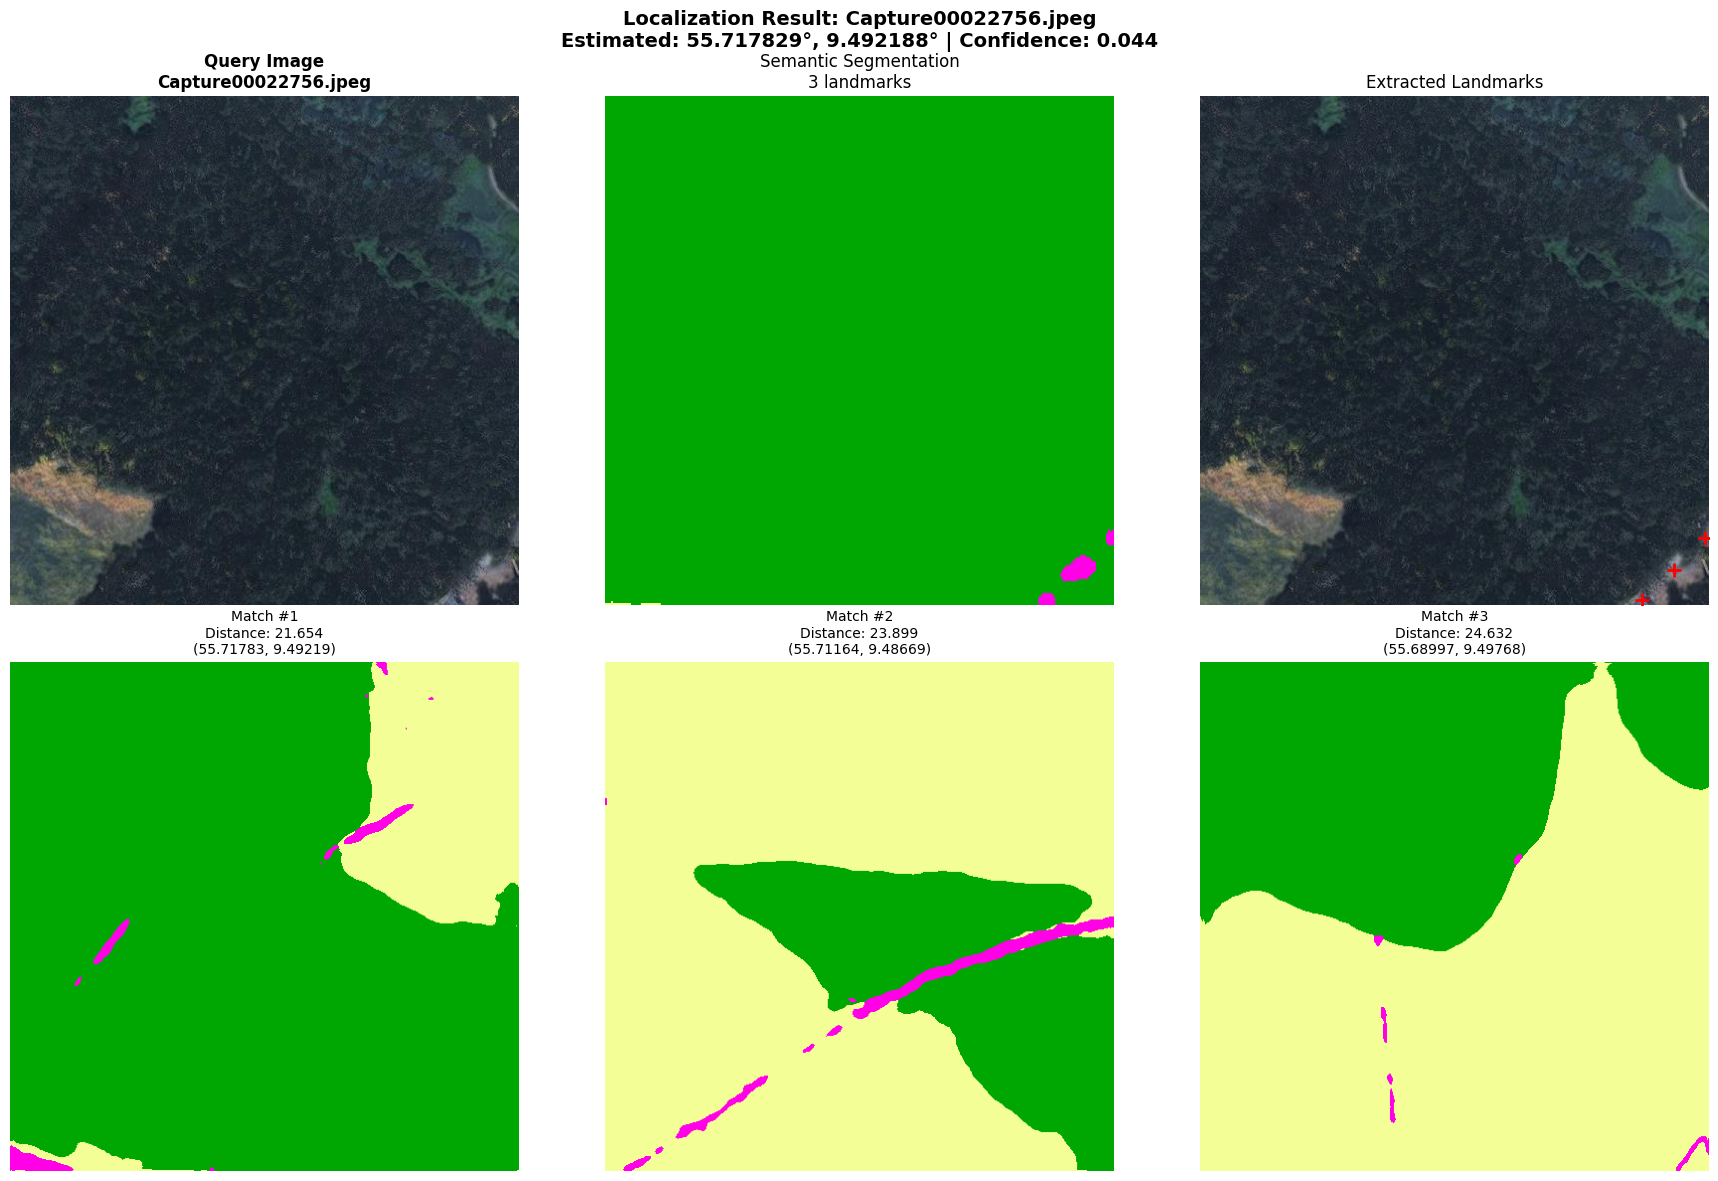


✓ Saved visualization to C:\Users\emilj\Documents\Thesis\TRAINING\localization_output\drone_route_test_roads_land_buildings_summer_model_1\sample_result_Capture00022756.png


In [23]:
# Visualize first sample
if result['success']:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Row 1: Query image, mask, landmarks
    axes[0, 0].imshow(result['image'])
    axes[0, 0].set_title(f"Query Image\n{test_img.name}", fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(result['mask'])
    axes[0, 1].set_title(f"Semantic Segmentation\n{result['num_landmarks']} landmarks", fontsize=12)
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(result['image'])
    for lm in result['landmarks'][:20]:  # Show first 20 landmarks
        cx, cy = lm['centroid']
        axes[0, 2].plot(cx, cy, 'r+', markersize=10, markeredgewidth=2)
    axes[0, 2].set_title("Extracted Landmarks", fontsize=12)
    axes[0, 2].axis('off')
    
    # Row 2: Top 3 matches
    for idx, match in enumerate(result['matches'][:3]):
        meta = match['metadata']
        match_path = Path(meta['prediction_path'])
        match_img = np.array(Image.open(match_path).convert('RGB'))
        
        axes[1, idx].imshow(match_img)
        title = f"Match #{match['rank']}\nDistance: {match['distance']:.3f}\n"
        title += f"({meta['lat']:.5f}, {meta['lon']:.5f})"
        axes[1, idx].set_title(title, fontsize=10)
        axes[1, idx].axis('off')
    
    plt.suptitle(f"Localization Result: {test_img.name}\n"
                 f"Estimated: {result['estimated_lat']:.6f}°, {result['estimated_lon']:.6f}° | "
                 f"Confidence: {result['confidence']:.3f}",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'sample_result_{test_img.stem}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Saved visualization to {OUTPUT_DIR / f'sample_result_{test_img.stem}.png'}")

## 4. Process Full Route

In [24]:
# ========================================
# TEST-TIME AUGMENTATION (TTA) CONFIGURATION
# ========================================

# Enable TTA for more robust localization (slower but potentially more accurate)
USE_TTA = True  # Set to False for faster processing without rotation augmentation

# TTA rotation angles to test (only used if USE_TTA=True)
TTA_ROTATIONS = [0, 90, 180, 270]  # Test all 4 orientations

if USE_TTA:
    print("="*60)
    print("⚡ TEST-TIME AUGMENTATION (TTA) ENABLED")
    print("="*60)
    print(f"  Rotations to test: {TTA_ROTATIONS}")
    print(f"  Expected slowdown: ~{len(TTA_ROTATIONS)}x")
    print(f"  Benefit: More robust matching across different orientations")
    print("="*60)
    localize_func = localize_image_tta
else:
    print("Standard localization (no TTA)")
    localize_func = localize_image

⚡ TEST-TIME AUGMENTATION (TTA) ENABLED
  Rotations to test: [0, 90, 180, 270]
  Expected slowdown: ~4x
  Benefit: More robust matching across different orientations


In [25]:
# Process all sampled images
print("\n" + "="*60)
print(f"PROCESSING FULL ROUTE: {len(sampled_images)} FRAMES")
if USE_TTA:
    print(f"MODE: Test-Time Augmentation with {len(TTA_ROTATIONS)} rotations")
else:
    print(f"MODE: Standard (no augmentation)")
print("="*60)

results = []
failed_count = 0

for img_path in tqdm(sampled_images, desc="Localizing"):
    if USE_TTA:
        result = localize_image_tta(
            img_path,
            model,
            transform,
            database,
            device,
            min_area=MIN_LANDMARK_AREA,
            max_triplets=MAX_TRIPLETS,
            top_k=TOP_K_MATCHES,
            rotations=TTA_ROTATIONS
        )
    else:
        result = localize_image(
            img_path,
            model,
            transform,
            database,
            device,
            min_area=MIN_LANDMARK_AREA,
            max_triplets=MAX_TRIPLETS,
            top_k=TOP_K_MATCHES
        )
    
    # Add frame number
    result['frame'] = int(img_path.stem.replace('Capture', ''))
    results.append(result)
    
    if not result['success']:
        failed_count += 1

print(f"\n✓ Route processing complete!")
print(f"  Total frames: {len(results)}")
print(f"  Successful: {len(results) - failed_count}")
print(f"  Failed: {failed_count}")
print(f"  Success rate: {100 * (len(results) - failed_count) / len(results):.1f}%")

if USE_TTA and any(r.get('success') for r in results):
    # Print TTA-specific statistics
    tta_votes = [r.get('tta_votes', 0) for r in results if r.get('success')]
    if tta_votes:
        avg_votes = sum(tta_votes) / len(tta_votes)
        print(f"\n  TTA Statistics:")
        print(f"    Average rotations agreeing: {avg_votes:.1f} / {len(TTA_ROTATIONS)}")
        print(f"    Consensus rate: {100*avg_votes/len(TTA_ROTATIONS):.1f}%")


PROCESSING FULL ROUTE: 90 FRAMES
MODE: Test-Time Augmentation with 4 rotations


Localizing:   0%|          | 0/90 [00:00<?, ?it/s]


✓ Route processing complete!
  Total frames: 90
  Successful: 88
  Failed: 2
  Success rate: 97.8%

  TTA Statistics:
    Average rotations agreeing: 3.0 / 4
    Consensus rate: 74.7%


In [26]:
# Save results to JSON
results_file = OUTPUT_DIR / "localization_results.json"

# Convert numpy arrays to lists for JSON serialization
json_results = []
for r in results:
    json_r = {
        'frame': r['frame'],
        'image_path': r['image_path'],
        'success': r['success'],
        'num_landmarks': r.get('num_landmarks', 0)
    }
    
    if r['success']:
        json_r['estimated_lat'] = r['estimated_lat']
        json_r['estimated_lon'] = r['estimated_lon']
        json_r['confidence'] = r['confidence']
        json_r['top_match_distance'] = r['matches'][0]['distance']
    else:
        json_r['error'] = r.get('error', 'Unknown')
    
    json_results.append(json_r)

with open(results_file, 'w') as f:
    json.dump(json_results, f, indent=2)

print(f"\n✓ Results saved to {results_file}")


✓ Results saved to C:\Users\emilj\Documents\Thesis\TRAINING\localization_output\drone_route_test_roads_land_buildings_summer_model_1\localization_results.json


## 5. Visualize Route

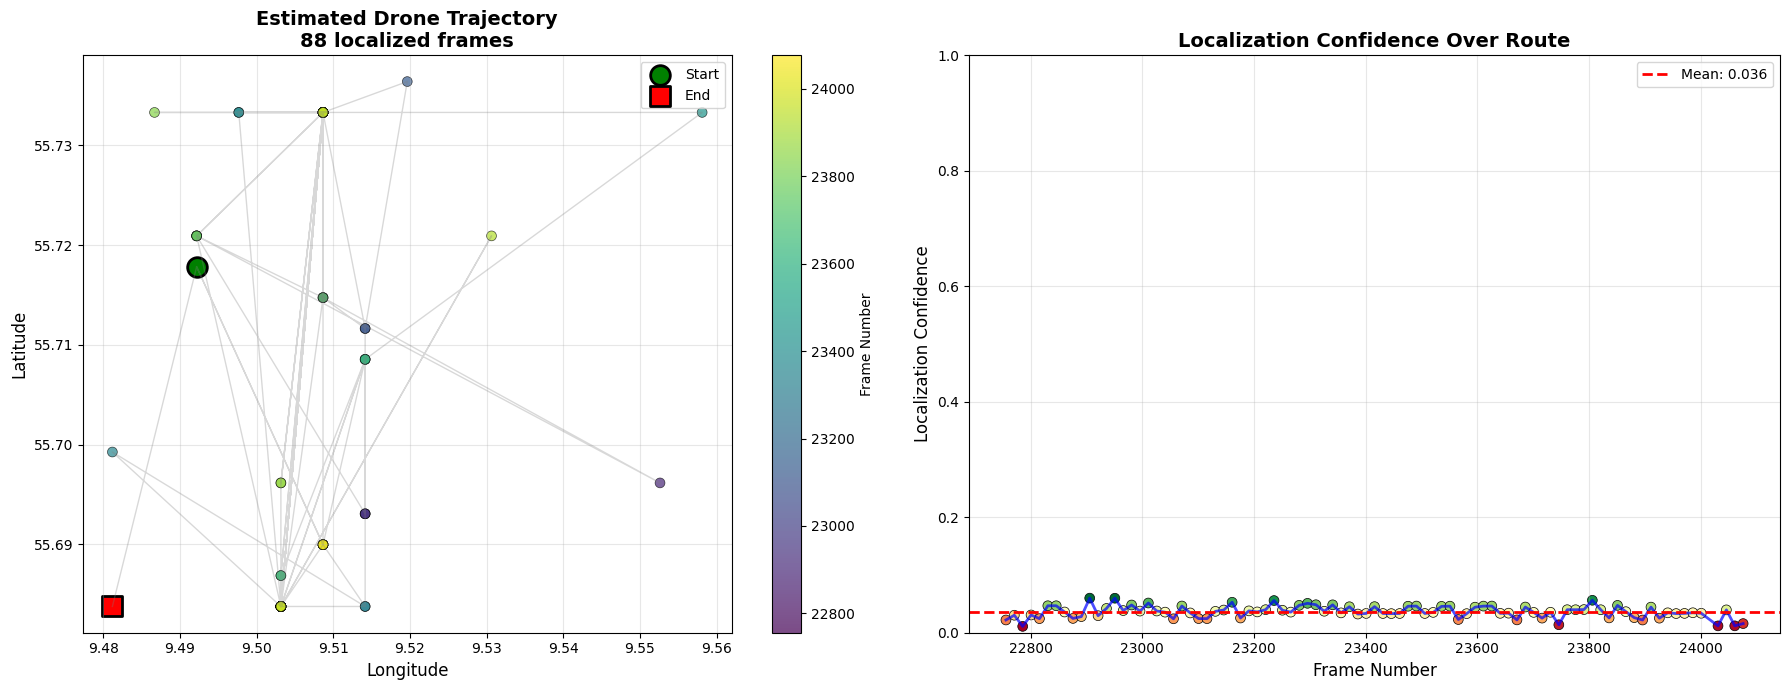


✓ Trajectory visualization saved to C:\Users\emilj\Documents\Thesis\TRAINING\localization_output\drone_route_test_roads_land_buildings_summer_model_1\route_trajectory.png

TRAJECTORY STATISTICS
Route length: 88 frames
Latitude range: 55.683779° to 55.736389°
Longitude range: 9.481201° to 9.558105°
Average confidence: 0.036
Min confidence: 0.011
Max confidence: 0.060


In [27]:
# Plot estimated trajectory
successful_results = [r for r in results if r['success']]

if successful_results:
    lats = [r['estimated_lat'] for r in successful_results]
    lons = [r['estimated_lon'] for r in successful_results]
    frames = [r['frame'] for r in successful_results]
    confidences = [r['confidence'] for r in successful_results]
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Trajectory map
    scatter = axes[0].scatter(lons, lats, c=frames, cmap='viridis', 
                              s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
    axes[0].plot(lons, lats, 'gray', alpha=0.3, linewidth=1)
    axes[0].scatter(lons[0], lats[0], color='green', s=200, marker='o', 
                    edgecolors='black', linewidth=2, label='Start')
    axes[0].scatter(lons[-1], lats[-1], color='red', s=200, marker='s', 
                    edgecolors='black', linewidth=2, label='End')
    axes[0].set_xlabel('Longitude', fontsize=12)
    axes[0].set_ylabel('Latitude', fontsize=12)
    axes[0].set_title(f'Estimated Drone Trajectory\n{len(successful_results)} localized frames', 
                      fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[0], label='Frame Number')
    
    # Confidence over time
    axes[1].plot(frames, confidences, 'b-', linewidth=2, alpha=0.7)
    axes[1].scatter(frames, confidences, c=confidences, cmap='RdYlGn', 
                    s=50, edgecolors='black', linewidth=0.5)
    axes[1].set_xlabel('Frame Number', fontsize=12)
    axes[1].set_ylabel('Localization Confidence', fontsize=12)
    axes[1].set_title('Localization Confidence Over Route', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0, 1])
    
    # Add statistics
    avg_conf = np.mean(confidences)
    axes[1].axhline(avg_conf, color='red', linestyle='--', linewidth=2, 
                    label=f'Mean: {avg_conf:.3f}')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'route_trajectory.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Trajectory visualization saved to {OUTPUT_DIR / 'route_trajectory.png'}")
    
    # Print statistics
    print("\n" + "="*60)
    print("TRAJECTORY STATISTICS")
    print("="*60)
    print(f"Route length: {len(successful_results)} frames")
    print(f"Latitude range: {min(lats):.6f}° to {max(lats):.6f}°")
    print(f"Longitude range: {min(lons):.6f}° to {max(lons):.6f}°")
    print(f"Average confidence: {avg_conf:.3f}")
    print(f"Min confidence: {min(confidences):.3f}")
    print(f"Max confidence: {max(confidences):.3f}")
else:
    print("No successful localizations to plot!")

## 6. Summary

In [28]:
print("\n" + "="*70)
print("DRONE ROUTE LOCALIZATION TEST - SUMMARY")
print("="*70)

print("\n📁 INPUT:")
print(f"  Route: {DRONE_IMAGES_DIR.name}")
print(f"  Frame range: Capture{START_FRAME:08d} to Capture{END_FRAME:08d}")
print(f"  Sampling: Every {SAMPLE_EVERY}th frame")
print(f"  Total frames processed: {len(results)}")

print("\n🤖 MODEL:")
print(f"  Architecture: UNet++ with EfficientNet-B3")
print(f"  Checkpoint: {MODEL_PATH.name}")
print(f"  Classes: {NUM_CLASSES} ({', '.join(CLASS_NAMES)})")

print("\n🗄️ DATABASE:")
print(f"  Entries: {len(database)}")
print(f"  Coverage: Vejle, Denmark")
print(f"  Feature dimension: {stats['feature_dimension']}")

print("\n📊 RESULTS:")
successful = len(successful_results)
total = len(results)
print(f"  Successful localizations: {successful}/{total} ({100*successful/total:.1f}%)")
print(f"  Failed: {total - successful}")

if successful_results:
    avg_landmarks = np.mean([r['num_landmarks'] for r in successful_results])
    print(f"  Average landmarks per frame: {avg_landmarks:.1f}")
    print(f"  Average confidence: {avg_conf:.3f}")

print("\n📁 OUTPUT FILES:")
print(f"  {results_file}")
print(f"  {OUTPUT_DIR / 'route_trajectory.png'}")
print(f"  {OUTPUT_DIR / f'sample_result_Capture{START_FRAME:08d}.png'}")

print("\n" + "="*70)
print("✓✓✓ DRONE ROUTE TEST COMPLETE! ✓✓✓")
print("="*70)

if successful / total < 0.5:
    print("\n⚠️ WARNING: Low success rate!")
    print("   Possible issues:")
    print("   - Drone route may be outside reference map coverage")
    print("   - Image quality or altitude differences")
    print("   - Try adjusting MIN_LANDMARK_AREA or MAX_TRIPLETS")
else:
    print("\n✓ Good localization performance!")
    print("  Next steps: Week 3-4 optimization for real-time performance")


DRONE ROUTE LOCALIZATION TEST - SUMMARY

📁 INPUT:
  Route: 1200ft AMSL 15fps
  Frame range: Capture00022756 to Capture00024091
  Sampling: Every 1th frame
  Total frames processed: 90

🤖 MODEL:
  Architecture: UNet++ with EfficientNet-B3
  Checkpoint: best.pth
  Classes: 6 (waterbodies, forest_trees, land, railway, roads, buildings)

🗄️ DATABASE:
  Entries: 258
  Coverage: Vejle, Denmark
  Feature dimension: 350

📊 RESULTS:
  Successful localizations: 88/90 (97.8%)
  Failed: 2
  Average landmarks per frame: 49.0
  Average confidence: 0.036

📁 OUTPUT FILES:
  C:\Users\emilj\Documents\Thesis\TRAINING\localization_output\drone_route_test_roads_land_buildings_summer_model_1\localization_results.json
  C:\Users\emilj\Documents\Thesis\TRAINING\localization_output\drone_route_test_roads_land_buildings_summer_model_1\route_trajectory.png
  C:\Users\emilj\Documents\Thesis\TRAINING\localization_output\drone_route_test_roads_land_buildings_summer_model_1\sample_result_Capture00022756.png

✓✓✓ DR

## 7. Ground Truth Comparison

Compare estimated trajectory against actual GPS ground truth to measure localization accuracy.

In [29]:
# Load ground truth GPS data
import pandas as pd

print("\n" + "="*60)
print("LOADING GROUND TRUTH GPS DATA")
print("="*60)

gps_df = pd.read_csv("GPS_extraction_output/coords.csv")

# Extract frame numbers from filenames
gps_df['frame'] = gps_df['filename'].str.extract(r'Capture(\d+)\.jpeg').astype(int)

# Filter to test range
gps_filtered = gps_df[(gps_df['frame'] >= START_FRAME) & (gps_df['frame'] <= END_FRAME)].copy()
gps_filtered = gps_filtered.sort_values('frame')

print(f"Ground truth GPS points: {len(gps_filtered)} (frames {START_FRAME}-{END_FRAME})")
print(f"Estimated GPS points: {len(successful_results)} / {len(results)} total frames")

# Match each estimated frame to nearest GPS frame
merged_list = []
for r in successful_results:
    # Find nearest GPS frame
    frame_diffs = abs(gps_filtered['frame'] - r['frame'])
    nearest_idx = frame_diffs.idxmin()
    nearest_gps = gps_filtered.loc[nearest_idx]
    
    # Only match if within 20 frames
    if frame_diffs[nearest_idx] <= 20:
        merged_list.append({
            'frame': r['frame'],
            'latitude_est': r['estimated_lat'],
            'longitude_est': r['estimated_lon'],
            'latitude_gt': nearest_gps['latitude'],
            'longitude_gt': nearest_gps['longitude'],
            'frame_diff': frame_diffs[nearest_idx]
        })

merged_df = pd.DataFrame(merged_list)
print(f"Frames matched: {len(merged_df)} / {len(results)} total")

if len(merged_df) == 0:
    print("⚠ Warning: No frames could be matched between GPS and test data")
else:
    # Calculate haversine distance error (in meters)
    def haversine_distance(lat1, lon1, lat2, lon2):
        """Calculate distance between two GPS points in meters"""
        R = 6371000  # Earth radius in meters
        phi1, phi2 = np.radians(lat1), np.radians(lat2)
        dphi = np.radians(lat2 - lat1)
        dlambda = np.radians(lon2 - lon1)
        
        a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
        
        return R * c
    
    merged_df['error_m'] = haversine_distance(
        merged_df['latitude_est'], merged_df['longitude_est'],
        merged_df['latitude_gt'], merged_df['longitude_gt']
    )
    
    # Print statistics
    print("\n" + "="*60)
    print("LOCALIZATION ERROR STATISTICS")
    print("="*60)
    print(f"Mean error: {merged_df['error_m'].mean():.2f} meters")
    print(f"Median error: {merged_df['error_m'].median():.2f} meters")
    print(f"Max error: {merged_df['error_m'].max():.2f} meters")
    print(f"Min error: {merged_df['error_m'].min():.2f} meters")
    print(f"Std dev: {merged_df['error_m'].std():.2f} meters")
    print("="*60)
    
    # Percentage within thresholds
    within_50m = (merged_df['error_m'] <= 50).sum() / len(merged_df) * 100
    within_100m = (merged_df['error_m'] <= 100).sum() / len(merged_df) * 100
    within_500m = (merged_df['error_m'] <= 500).sum() / len(merged_df) * 100
    
    print(f"\nAccuracy thresholds:")
    print(f"  Within  50m: {within_50m:.1f}%")
    print(f"  Within 100m: {within_100m:.1f}%")
    print(f"  Within 500m: {within_500m:.1f}%")


LOADING GROUND TRUTH GPS DATA
Ground truth GPS points: 133 (frames 22756-24091)
Estimated GPS points: 88 / 90 total frames
Frames matched: 88 / 90 total

LOCALIZATION ERROR STATISTICS
Mean error: 2780.12 meters
Median error: 2922.76 meters
Max error: 5976.44 meters
Min error: 129.99 meters
Std dev: 1295.57 meters

Accuracy thresholds:
  Within  50m: 0.0%
  Within 100m: 0.0%
  Within 500m: 5.7%



✓ Plot saved to: C:\Users\emilj\Documents\Thesis\TRAINING\localization_output\drone_route_test_roads_land_buildings_summer_model_1\trajectory_comparison.png


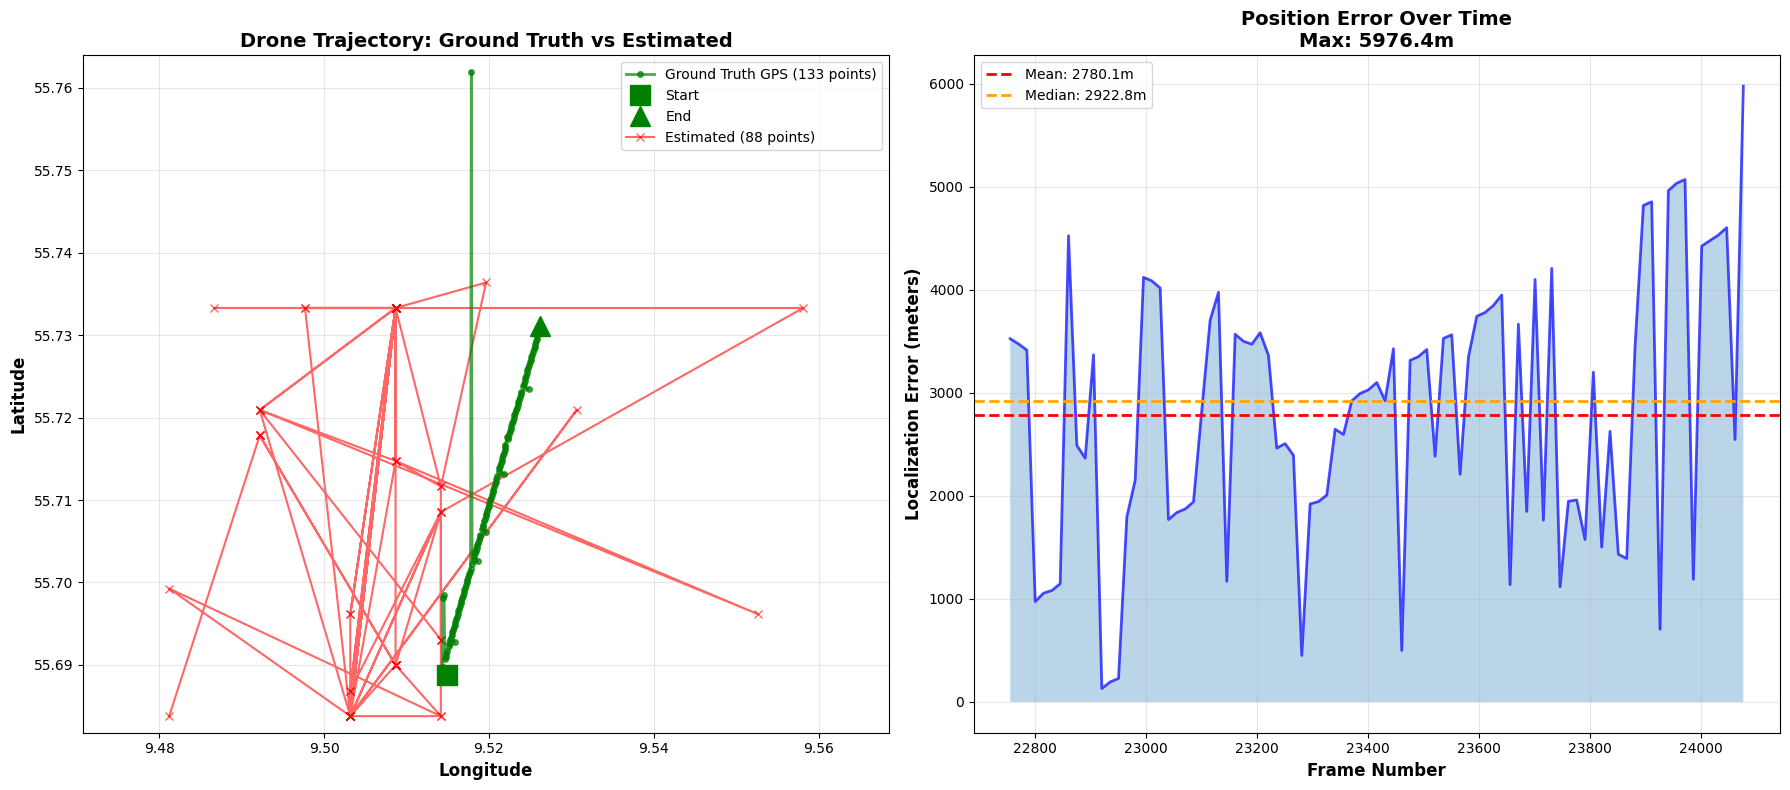

In [30]:
# Create trajectory comparison visualization
if len(merged_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # --- Plot 1: Full trajectory comparison ---
    ax1 = axes[0]
    
    # Plot ground truth
    if len(gps_filtered) > 0:
        ax1.plot(gps_filtered['longitude'], gps_filtered['latitude'], 
                 'g-o', linewidth=2, markersize=4, alpha=0.7, 
                 label=f'Ground Truth GPS ({len(gps_filtered)} points)', zorder=2)
        
        # Mark start and end
        ax1.plot(gps_filtered.iloc[0]['longitude'], gps_filtered.iloc[0]['latitude'],
                 'gs', markersize=15, label='Start', zorder=3)
        ax1.plot(gps_filtered.iloc[-1]['longitude'], gps_filtered.iloc[-1]['latitude'],
                 'g^', markersize=15, label='End', zorder=3)
    
    # Plot estimated trajectory
    if len(successful_results) > 0:
        est_lons = [r['estimated_lon'] for r in successful_results]
        est_lats = [r['estimated_lat'] for r in successful_results]
        ax1.plot(est_lons, est_lats,
                 'r-x', linewidth=1.5, markersize=6, alpha=0.6,
                 label=f'Estimated ({len(successful_results)} points)', zorder=1)
    
    ax1.set_xlabel('Longitude', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Latitude', fontsize=12, fontweight='bold')
    ax1.set_title('Drone Trajectory: Ground Truth vs Estimated', 
                  fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.axis('equal')
    
    # --- Plot 2: Point-by-point error ---
    ax2 = axes[1]
    
    # Plot error over time
    ax2.plot(merged_df['frame'], merged_df['error_m'], 'b-', linewidth=2, alpha=0.7)
    ax2.fill_between(merged_df['frame'], 0, merged_df['error_m'], alpha=0.3)
    
    # Add statistics
    mean_error = merged_df['error_m'].mean()
    median_error = merged_df['error_m'].median()
    max_error = merged_df['error_m'].max()
    
    ax2.axhline(mean_error, color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {mean_error:.1f}m')
    ax2.axhline(median_error, color='orange', linestyle='--', linewidth=2,
                label=f'Median: {median_error:.1f}m')
    
    ax2.set_xlabel('Frame Number', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Localization Error (meters)', fontsize=12, fontweight='bold')
    ax2.set_title(f'Position Error Over Time\nMax: {max_error:.1f}m', 
                  fontsize=14, fontweight='bold')
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save the figure
    output_file = OUTPUT_DIR / "trajectory_comparison.png"
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"\n✓ Plot saved to: {output_file}")
    
    plt.show()
else:
    print("\n⚠ No matching data available for trajectory comparison")